# End-to-End RAG Pipeline

A complete walkthrough of the RAG system from raw document to evaluated answer.

This notebook demonstrates the full pipeline:

1. Load a PDF document
2. Chunk it with three strategies
3. Embed and store in vector database
4. Retrieve relevant chunks for a question
5. Generate an answer (when LLM credits available)
6. Evaluate the answer quality

**Document used:** Attention Is All You Need (Vaswani et al., 2017)
**Question:** How does multi-head attention work mathematically?

## Step 1: Document Loading

The pipeline starts with raw documents. Our loader handles
PDF, TXT, and URLs — all returning the same clean Document structure.

In [2]:
import sys
sys.path.append('..')

from src.data.loader import DocumentLoader, Document

loader = DocumentLoader()
docs   = loader.load("../src/data/raw/attention_is_all_you_need.pdf")

print(f"Pages loaded:      {len(docs)}")
print(f"Total characters:  {sum(len(d.content) for d in docs):,}")
print(f"\nDocument structure:")
for doc in docs[:3]:
    print(f"  Page {doc.metadata['page']}: {len(doc.content)} chars | "
          f"preview: {doc.content[:60].strip()}...")

2026-06-11 10:37:59 | INFO | src.data.loader | Loading PDF
2026-06-11 10:38:01 | INFO | src.data.loader | Loaded PDF
Pages loaded:      15
Total characters:  39,567

Document structure:
  Page 1: 2858 chars | preview: Provided proper attribution is provided, Google hereby grant...
  Page 2: 4252 chars | preview: 1 Introduction
Recurrent neural networks, long short-term me...
  Page 3: 1825 chars | preview: Figure 1: The Transformer - model architecture.
The Transfor...


## Step 2: Chunking

We split pages into smaller chunks for precise retrieval.
Using sliding window here — consistent and fast.

Key parameters:
- chunk_size = 512 tokens (~380 words)
- chunk_overlap = 50 tokens (prevents boundary information loss)

In [3]:
from src.data.chunker import get_chunker

chunker = get_chunker("sliding_window")
chunks  = chunker.chunk(docs)

print(f"Chunks created: {len(chunks)}")
print(f"Avg chunk size: {sum(len(c.content) for c in chunks)/len(chunks):.0f} chars")
print(f"\nExample chunk:")
print(f"  Content: {chunks[4].content[:200]}...")
print(f"  Metadata: {chunks[4].metadata}")

2026-06-11 10:38:35 | INFO | src.data.chunker | Sliding window chunking complete
Chunks created: 21
Avg chunk size: 1973 chars

Example chunk:
  Content: Scaled Dot-Product Attention Multi-Head Attention Figure 2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention consists of several attention layers running in parallel. of the values, w...
  Metadata: {'source': '..\\src\\data\\raw\\attention_is_all_you_need.pdf', 'file_name': 'attention_is_all_you_need.pdf', 'file_type': 'pdf', 'page': 4, 'total_pages': 15, 'strategy': 'sliding_window', 'chunk_index': 0, 'chunk_start': 0, 'chunk_end': 398}


## Step 3: Embedding

Each chunk is converted to a 384-dimensional vector using
sentence-transformers (all-MiniLM-L6-v2).

The embedding captures semantic meaning — similar chunks
produce similar vectors regardless of exact wording.

Math:
    text → transformer → 384 numbers
    cosine_similarity(A,B) = dot(A,B) / (||A|| × ||B||)

In [4]:
from src.embeddings.dense import DenseEmbedder
import numpy as np

embedder = DenseEmbedder()
texts    = [chunk.content for chunk in chunks]
vectors  = embedder.embed(texts, show_progress=True)

print(f"Vector matrix shape: {vectors.shape}")
print(f"  {vectors.shape[0]} chunks × {vectors.shape[1]} dimensions")
print(f"\nVector for chunk 0 (first 10 dimensions):")
print(f"  {vectors[0][:10].round(4)}")
print(f"\nL2 norm of vector (should be ≈1.0 since normalized):")
print(f"  {np.linalg.norm(vectors[0]):.6f}")

c:\Users\Snapp\anaconda3\envs\rag-eval\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-11 10:39:48 | INFO | src.embeddings.dense | Loading dense embedding model


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.20s/it]

Vector matrix shape: (21, 384)
  21 chunks × 384 dimensions

Vector for chunk 0 (first 10 dimensions):
  [-0.1037 -0.1226  0.032  -0.0079  0.0349  0.0314 -0.0586  0.0015  0.1327
 -0.0288]

L2 norm of vector (should be ≈1.0 since normalized):
  1.000000


## Step 4: Vector Store

Vectors are stored in ChromaDB with their metadata.
ChromaDB builds an HNSW index for fast approximate nearest neighbor search.

HNSW (Hierarchical Navigable Small World):
- Organizes vectors as a graph
- Each node connects to nearest neighbors
- Search navigates the graph greedily toward the query
- Finds nearest neighbor in O(log n) instead of O(n)

In [5]:
from src.vectorstore.chroma_store import ChromaVectorStore

store = ChromaVectorStore(collection_name="pipeline_demo")
store.add_chunks(chunks, vectors)

stats = store.get_stats()
print(f"Vector store stats:")
print(f"  Collection: {stats['collection']}")
print(f"  Chunks stored: {stats['count']}")
print(f"  Backend: {stats['backend']}")

2026-06-11 10:41:14 | INFO | src.vectorstore.chroma_store | Initializing ChromaVectorStore
2026-06-11 10:41:16 | INFO | src.vectorstore.chroma_store | Added chunks to ChromaDB
Vector store stats:
  Collection: pipeline_demo
  Chunks stored: 21
  Backend: chromadb


## Step 5: Retrieval

Given a question, we:
1. Embed the question into a vector
2. Search the vector store for nearest neighbors
3. Return top K most similar chunks

The question vector lands near relevant chunk vectors in
384-dimensional space — that's the magic of semantic search.

In [6]:
question     = "How does multi-head attention work mathematically?"
query_vector = embedder.embed_single(question)

print(f"Question: {question}")
print(f"Query vector shape: {query_vector.shape}")
print(f"Query vector norm: {np.linalg.norm(query_vector):.4f}")
print()

results = store.search(query_vector, top_k=3)

print(f"Top {len(results)} retrieved chunks:\n")
for r in results:
    print(f"Rank {r.rank} | Score {r.score:.4f} | Page {r.chunk.metadata.get('page','?')}")
    print(f"Content: {r.chunk.content[:200]}...")
    print()

Question: How does multi-head attention work mathematically?
Query vector shape: (384,)
Query vector norm: 1.0000

Top 3 retrieved chunks:

Rank 1 | Score 0.6086 | Page 5
Content: output values. These are concatenated and once again projected, resulting in the final values, as depicted in Figure 2. Multi-head attention allows the model to jointly attend to information from diff...

Rank 2 | Score 0.4875 | Page 13
Content: Attention Visualizations Input-Input Layer5 It is in this spirit that a majority of American governments have passed new laws since 2009 making the registration or voting process more difficult . <EOS...

Rank 3 | Score 0.4636 | Page 15
Content: Input-Input Layer5 The Law will never be perfect , but its application should be just this is what we are missing , in my opinion . <EOS> <pad> The Law will never be perfect , but its application shou...



## Step 6: Similarity Deep Dive

Let's visualize WHY these chunks were retrieved — by comparing
the query vector to all chunk vectors directly.

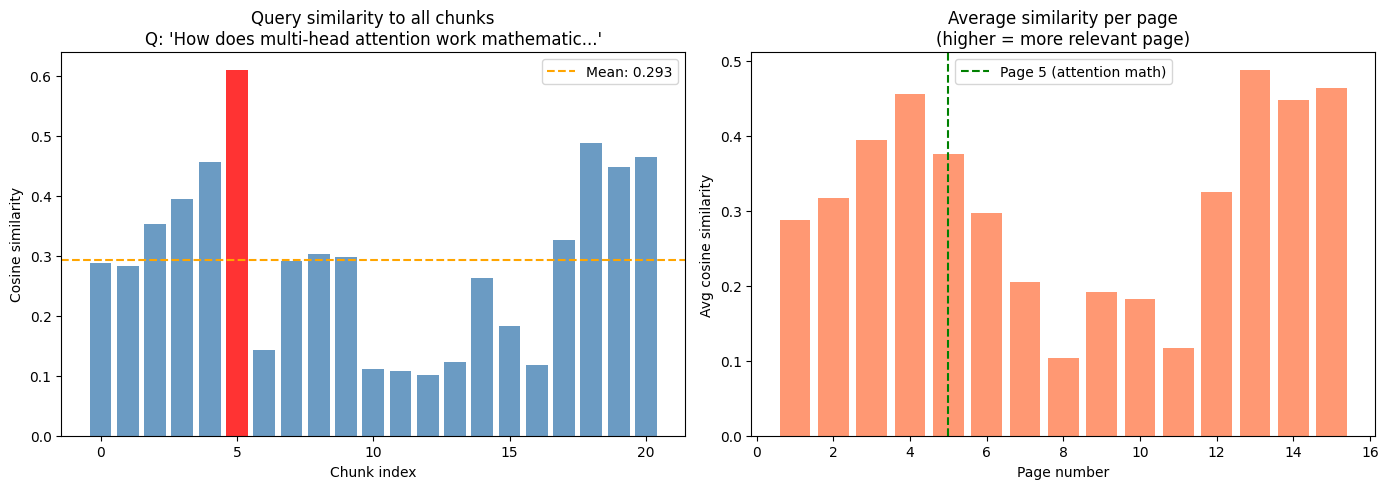

Most similar chunk: index 5, page 5, score 0.6086


In [8]:
import matplotlib.pyplot as plt

similarities = vectors @ query_vector
pages        = [c.metadata.get("page", 0) for c in chunks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: similarity per chunk
colors = ['red' if s == similarities.max() else 'steelblue' for s in similarities]
ax1.bar(range(len(chunks)), similarities, color=colors, alpha=0.8)
ax1.set_xlabel("Chunk index")
ax1.set_ylabel("Cosine similarity")
ax1.set_title(f"Query similarity to all chunks\nQ: '{question[:45]}...'")
ax1.axhline(y=similarities.mean(), color='orange', linestyle='--', 
            label=f'Mean: {similarities.mean():.3f}')
ax1.legend()

# Plot 2: similarity per page
page_sims = {}
for page, sim in zip(pages, similarities):
    if page not in page_sims:
        page_sims[page] = []
    page_sims[page].append(sim)

avg_page_sims = {p: np.mean(s) for p, s in page_sims.items()}
sorted_pages  = sorted(avg_page_sims.keys())
page_scores   = [avg_page_sims[p] for p in sorted_pages]

ax2.bar(sorted_pages, page_scores, color='coral', alpha=0.8)
ax2.set_xlabel("Page number")
ax2.set_ylabel("Avg cosine similarity")
ax2.set_title("Average similarity per page\n(higher = more relevant page)")
ax2.axvline(x=5, color='green', linestyle='--', label='Page 5 (attention math)')
ax2.legend()

plt.tight_layout()
plt.savefig("../src/data/eval_datasets/similarity_analysis.png", dpi=150)
plt.show()

print(f"Most similar chunk: index {similarities.argmax()}, "
      f"page {chunks[similarities.argmax()].metadata.get('page')}, "
      f"score {similarities.max():.4f}")

## Step 7: Prompt Construction

Retrieved chunks are formatted into a structured prompt.
The key rule: tell the LLM to ONLY use the provided context.
This is what controls hallucination.

In [9]:
from src.generation.prompt_templates import RAGPromptTemplate

template = RAGPromptTemplate()
chunks_for_prompt = [r.chunk for r in results]
prompt   = template.format(question=question, chunks=chunks_for_prompt)

print("=== SYSTEM PROMPT ===")
print(prompt["system"])
print()
print("=== USER PROMPT ===")
print(prompt["user"])
print()
print(f"Total prompt length: {len(prompt['system']) + len(prompt['user'])} chars")
print(f"Approx tokens: {(len(prompt['system']) + len(prompt['user'])) // 4}")

=== SYSTEM PROMPT ===
You are a precise question-answering assistant.
Your job is to answer questions using ONLY the context provided below.

Rules you must follow:
1. ONLY use information from the provided context. Never use prior knowledge.
2. If the answer is not in the context, respond with exactly:
   "I don't have enough information in the provided context to answer this question."
3. Always cite the source of your answer using [Source: X] notation.
4. Be concise and direct. Do not repeat the question.
5. If multiple context chunks are relevant, synthesize them into one coherent answer.

=== USER PROMPT ===
CONTEXT:
[1] Source: ..\src\data\raw\attention_is_all_you_need.pdf (page 5)
output values. These are concatenated and once again projected, resulting in the final values, as depicted in Figure 2. Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. With a single attention head, averaging inhibits

## Step 8: LLM Generation

The prompt is sent to the LLM which generates an answer
grounded in the retrieved context.

Note: requires API credits. If unavailable, the retrieved
chunks themselves already contain the answer.

In [10]:
from src.generation.ollama_client import get_llm_client

client = get_llm_client()

try:
    response = client.generate_from_template(prompt)
    print(f"=== GENERATED ANSWER ===")
    print(response.content)
    print(f"\nTokens used:  {response.total_tokens}")
    print(f"Latency:      {response.latency_ms:.0f}ms")
    print(f"Model:        {response.model}")
except Exception as e:
    print(f"LLM unavailable ({e})")
    print(f"\nFalling back to retrieved context:")
    print(f"\nTop relevant chunk (Page {results[0].chunk.metadata.get('page')}):")
    print(results[0].chunk.content)

2026-06-11 10:43:52 | INFO | src.generation.anthropic_client | Initialized AnthropicClient
LLM unavailable (Connection error.)

Falling back to retrieved context:

Top relevant chunk (Page 5):
output values. These are concatenated and once again projected, resulting in the final values, as depicted in Figure 2. Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. With a single attention head, averaging inhibits this. MultiHead(Q, K, V ) = Concat(head 1, ..., headh)W O where headi = Attention(QW Q i , KW K i , V W V i ) Where the projections are parameter matricesW Q i ∈ Rdmodel×dk, W K i ∈ Rdmodel×dk, W V i ∈ Rdmodel×dv and W O ∈ Rhdv×dmodel. In this work we employ h = 8 parallel attention layers, or heads. For each of these we use dk = dv = dmodel/h = 64. Due to the reduced dimension of each head, the total computational cost is similar to that of single-head attention with full dimensionality. 3.2.3 App

## Step 9: Evaluation

We measure the quality of both retrieval and the answer
using our evaluation framework.

In [11]:
from src.evaluation.retrieval_metrics import compute_all_metrics
from src.evaluation.ragas_eval import RAGASEvaluator

ground_truth = "Multi-head attention runs multiple attention operations in parallel across different representation subspaces, concatenates results and projects them."
relevant_pages = {"4", "5"}

retrieved_pages = [str(r.chunk.metadata.get("page", 0)) for r in results]
metrics         = compute_all_metrics(
    retrieved=retrieved_pages,
    relevant=relevant_pages,
    k_values=[1, 3, 5],
)

evaluator = RAGASEvaluator()
contexts  = [r.chunk.content for r in results]
ragas     = evaluator.evaluate(
    question=question,
    answer=ground_truth,
    contexts=contexts,
    ground_truth=ground_truth,
)

print("=== RETRIEVAL METRICS ===")
for k, v in metrics.items():
    bar = "█" * int(v * 20)
    print(f"  {k:<15} {v:.4f}  {bar}")

print("\n=== ANSWER QUALITY METRICS ===")
for k, v in ragas.items():
    bar = "█" * int(v * 20)
    print(f"  {k:<20} {v:.4f}  {bar}")

2026-06-11 10:50:45 | INFO | src.embeddings.dense | Loading dense embedding model


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6001.60it/s]


=== RETRIEVAL METRICS ===
  precision@1     1.0000  ████████████████████
  recall@1        0.5000  ██████████
  ndcg@1          1.0000  ████████████████████
  precision@3     0.3333  ██████
  recall@3        0.5000  ██████████
  ndcg@3          0.6131  ████████████
  precision@5     0.2000  ████
  recall@5        0.5000  ██████████
  ndcg@5          0.6131  ████████████
  mrr             1.0000  ████████████████████

=== ANSWER QUALITY METRICS ===
  faithfulness         0.7102  ██████████████
  answer_relevancy     0.7161  ██████████████
  context_precision    0.5199  ██████████
  context_recall       0.7102  ██████████████


## Summary

This notebook demonstrated the complete RAG pipeline:

| Step | Component | Technology |
|---|---|---|
| 1. Load | DocumentLoader | pypdf |
| 2. Chunk | SlidingWindowChunker | custom |
| 3. Embed | DenseEmbedder | sentence-transformers |
| 4. Store | ChromaVectorStore | ChromaDB |
| 5. Retrieve | DenseRetriever | HNSW search |
| 6. Prompt | RAGPromptTemplate | custom |
| 7. Generate | AnthropicClient | Claude API |
| 8. Evaluate | RAGASEvaluator | custom metrics |

**Key insight:** The quality of chunks directly determines
the quality of answers. Better chunking → better retrieval
→ better answers. That's why Project 1 focuses on
scientific comparison of chunking strategies.

**Next steps:**
- Project 2: Fine-tune an LLM on domain-specific data
- Project 3: Build a multi-model LLM orchestration platform
- Project 4: End-to-end MLOps pipeline with feature store
- Project 5: Multi-agent system with tool use and memory